# IndoBERT Baseline: t-SNE Visualization

Compare t-SNE embeddings from **IndoBERT encoder only** (no DANN, no adapters) against the DANN + Adapters approach.

Run cells **top to bottom**.

In [1]:
import json
import os
import random
from pathlib import Path
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Try to import umap for optional projection
try:
    import umap
    _HAVE_UMAP = True
except Exception:
    _HAVE_UMAP = False

print('Device:', torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4060


In [2]:
# =========================
# 1) Configuration
# =========================
CFG = {
    'model_name': 'indolem/indobert-base-uncased',
    'source_csv': '../../datasets/telemedicine_preprocessed/train.csv',
    'target_csv': '../../datasets/lazada_train_preprocessed.csv',
    'eval_csv': '../../datasets/lazada_test_preprocessed.csv',
    'output_dir': 'outputs/indobert_baseline',
    
    'batch_size': 32,
    'max_length': 128,
    'seed': 42,
    'max_samples_per_domain': 2000,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG['seed'])

# Verify dataset paths
for key in ['source_csv', 'target_csv', 'eval_csv']:
    path = Path(CFG[key])
    exists = path.exists()
    print(f"{key}: {CFG[key]} -> {'✓' if exists else '✗'}")

# Create output directory
Path(CFG['output_dir']).mkdir(parents=True, exist_ok=True)
print(f"\nOutput dir: {CFG['output_dir']}")

source_csv: ../../datasets/telemedicine_preprocessed/train.csv -> ✓
target_csv: ../../datasets/lazada_train_preprocessed.csv -> ✓
eval_csv: ../../datasets/lazada_test_preprocessed.csv -> ✓

Output dir: outputs/indobert_baseline


In [3]:
# =========================
# 2) Utility Functions
# =========================
LABEL2ID = {'negative': 0, 'positive': 1}
ID2LABEL = {0: 'negative', 1: 'positive'}

def _resolve_text_column(df: pd.DataFrame) -> str:
    for col in ['content', 'reviewContent', 'text', 'review']:
        if col in df.columns:
            return col
    raise ValueError(f'Cannot find text column. Available: {df.columns.tolist()}')

def _resolve_label_column(df: pd.DataFrame) -> str:
    for col in ['label', 'sentiment', 'target']:
        if col in df.columns:
            return col
    raise ValueError(f'Cannot find label column. Available: {df.columns.tolist()}')

def _normalize_labels(series: pd.Series) -> pd.Series:
    normalized = series.astype(str).str.strip().str.lower()
    return normalized.replace({'neg': 'negative', 'pos': 'positive'})

def clean_dataframe(df: pd.DataFrame, text_col: str, label_col: Optional[str] = None) -> pd.DataFrame:
    use_cols = [text_col] + ([label_col] if label_col else [])
    out = df[use_cols].copy()
    out = out.dropna(subset=[text_col])
    out[text_col] = out[text_col].astype(str).str.strip()
    out = out[out[text_col] != '']
    
    if label_col:
        out = out.dropna(subset=[label_col])
        out[label_col] = _normalize_labels(out[label_col])
        out = out[out[label_col].isin(LABEL2ID)]
    
    return out.reset_index(drop=True)

class TextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128, labels=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt',
        )
        
        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
        }
        
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return item

print("✓ Utility functions loaded")

✓ Utility functions loaded


In [4]:
# =========================
# 3) Load IndoBERT Model
# =========================
print("Loading IndoBERT tokenizer and encoder...")
tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased")
encoder = AutoModel.from_pretrained(CFG['model_name']).to(device)
encoder.eval()

hidden_size = encoder.config.hidden_size
print(f"✓ IndoBERT loaded | hidden_size={hidden_size} | device={device}")

Loading IndoBERT tokenizer and encoder...
✓ IndoBERT loaded | hidden_size=768 | device=cuda


In [5]:
# =========================
# 4) Load and Clean Datasets
# =========================
print("Loading source dataset...")
source_df = pd.read_csv(CFG['source_csv'])
source_text_col = _resolve_text_column(source_df)
source_label_col = _resolve_label_column(source_df)
source_df = clean_dataframe(source_df, source_text_col, source_label_col)
source_df['label_id'] = source_df[source_label_col].map(LABEL2ID)
print(f"  Source: {len(source_df)} samples")
print(f"  Class distribution:\n{source_df['label_id'].value_counts().sort_index()}")

print("\nLoading target (eval) dataset...")
target_df = pd.read_csv(CFG['eval_csv'])
target_text_col = _resolve_text_column(target_df)
target_label_col = _resolve_label_column(target_df)

# Filter to target origin if column exists
if 'origin' in target_df.columns:
    origin = target_df['origin'].astype(str).str.lower()
    target_df = target_df[origin == 'target']
    print(f"  Filtered to 'target' origin: {len(target_df)} samples")

target_df = clean_dataframe(target_df, target_text_col, target_label_col)
target_df['label_id'] = target_df[target_label_col].map(LABEL2ID)
print(f"  Target: {len(target_df)} samples")
print(f"  Class distribution:\n{target_df['label_id'].value_counts().sort_index()}")

Loading source dataset...
  Source: 6696 samples
  Class distribution:
label_id
0    3348
1    3348
Name: count, dtype: int64

Loading target (eval) dataset...
  Target: 2042 samples
  Class distribution:
label_id
0    1020
1    1022
Name: count, dtype: int64


In [6]:
# =========================
# 5) Build DataLoaders
# =========================
print("Creating datasets...")
source_ds = TextDataset(
    texts=source_df[source_text_col].tolist(),
    labels=source_df['label_id'].tolist(),
    tokenizer=tokenizer,
    max_length=CFG['max_length'],
)

target_ds = TextDataset(
    texts=target_df[target_text_col].tolist(),
    labels=target_df['label_id'].tolist(),
    tokenizer=tokenizer,
    max_length=CFG['max_length'],
)

source_loader = DataLoader(source_ds, batch_size=CFG['batch_size'], shuffle=False)
target_loader = DataLoader(target_ds, batch_size=CFG['batch_size'], shuffle=False)

print(f"✓ Source loader: {len(source_loader)} batches ({len(source_ds)} samples)")
print(f"✓ Target loader: {len(target_loader)} batches ({len(target_ds)} samples)")

Creating datasets...
✓ Source loader: 210 batches (6696 samples)
✓ Target loader: 64 batches (2042 samples)


In [7]:
# =========================
# 6) Extract IndoBERT Embeddings
# =========================
def extract_embeddings_indobert(encoder, dataloader, device, max_samples=None):
    """Extract [CLS] token embeddings from IndoBERT encoder."""
    encoder.eval()
    embeddings = []
    labels = []
    sample_count = 0
    
    with torch.no_grad():
        for batch in dataloader:
            if max_samples is not None and sample_count >= max_samples:
                break
                
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            batch_labels = batch['labels'].cpu().numpy()
            
            # Get encoder output and extract [CLS] token (first token)
            outputs = encoder(input_ids=input_ids, attention_mask=attention_mask)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [batch_size, hidden_size]
            
            embeddings.append(cls_embeddings.cpu().numpy())
            labels.extend(batch_labels.tolist())
            sample_count += len(batch_labels)
    
    if not embeddings:
        return np.zeros((0, encoder.config.hidden_size)), np.array([])
    
    return np.concatenate(embeddings, axis=0), np.array(labels)

print("Extracting source embeddings...")
X_source, y_source = extract_embeddings_indobert(
    encoder,
    source_loader,
    device,
    max_samples=CFG['max_samples_per_domain']
)
print(f"  Source embeddings: shape={X_source.shape}, labels={len(y_source)}")

print("\nExtracting target embeddings...")
X_target, y_target = extract_embeddings_indobert(
    encoder,
    target_loader,
    device,
    max_samples=CFG['max_samples_per_domain']
)
print(f"  Target embeddings: shape={X_target.shape}, labels={len(y_target)}")

# Combine for unified t-SNE projection
X_combined = np.concatenate([X_source, X_target], axis=0)
y_combined = np.concatenate([y_source, y_target], axis=0)
domains = ['source'] * len(y_source) + ['target'] * len(y_target)

print(f"\n✓ Combined embeddings: shape={X_combined.shape}")

Extracting source embeddings...
  Source embeddings: shape=(2016, 768), labels=2016

Extracting target embeddings...
  Target embeddings: shape=(2016, 768), labels=2016

✓ Combined embeddings: shape=(4032, 768)


In [8]:
# =========================
# 7) Compute t-SNE Projection
# =========================
print("Computing t-SNE projection (this may take a minute)...")

# Apply PCA first if necessary (speeds up t-SNE)
if X_combined.shape[1] > 50:
    print("  Applying PCA to reduce dimensionality...")
    pca = PCA(n_components=50, random_state=CFG['seed'])
    X_pca = pca.fit_transform(X_combined)
    print(f"  PCA output shape: {X_pca.shape}")
else:
    X_pca = X_combined

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=CFG['seed'], perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

print(f"✓ t-SNE projection complete: shape={X_tsne.shape}")

# Also split projections for separate visualization
X_tsne_source = X_tsne[:len(y_source)]
X_tsne_target = X_tsne[len(y_source):]

print(f"  Source projection: {X_tsne_source.shape}")
print(f"  Target projection: {X_tsne_target.shape}")

Computing t-SNE projection (this may take a minute)...
  Applying PCA to reduce dimensionality...
  PCA output shape: (4032, 50)
✓ t-SNE projection complete: shape=(4032, 2)
  Source projection: (2016, 2)
  Target projection: (2016, 2)


  Saved: outputs\indobert_baseline\tsne_indobert_combined.png


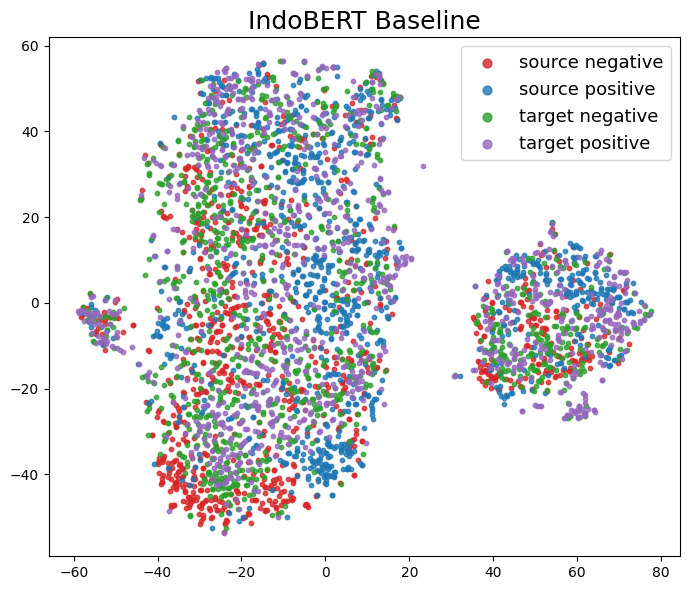

In [9]:
# =========================
# 8) Plot t-SNE Combined (Source + Target)
# =========================
def plot_tsne_combined(proj, labels, domains, title, figsize=(7, 6), outpath=None):
    """Plot t-SNE using the same visual style as the DANN notebook."""
    palette = {
        ('source', 0): '#d62728',  # red
        ('source', 1): '#1f77b4',  # blue
        ('target', 0): '#2ca02c',  # green
        ('target', 1): '#9467bd',  # black
    }
    display_names = {
        ('source', 0): 'source negative',
        ('source', 1): 'source positive',
        ('target', 0): 'target negative',
        ('target', 1): 'target positive',
    }
    plot_order = [('source', 0), ('source', 1), ('target', 0), ('target', 1)]

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    domains_np = np.array(domains)
    xs, ys = proj[:, 0], proj[:, 1]

    for dom, lab in plot_order:
        mask = (domains_np == dom) & (labels == lab)
        if mask.sum() == 0:
            continue
        ax.scatter(
            xs[mask],
            ys[mask],
            s=10,
            c=palette[(dom, lab)],
            label=display_names[(dom, lab)],
            alpha=0.8,
        )

    ax.set_title(title, fontsize=18)
    ax.grid(False)
    ax.legend(loc='upper right', fontsize=13, frameon=True, markerscale=2)

    fig.tight_layout()
    if outpath:
        fig.savefig(outpath, dpi=200)
        print(f"  Saved: {outpath}")
    plt.show()

# Plot combined
plot_tsne_combined(
    X_tsne,
    y_combined,
    domains,
    title='IndoBERT Baseline',
    figsize=(7, 6),
    outpath=Path(CFG['output_dir']) / 'tsne_indobert_combined.png'
)

In [10]:
# # =========================
# # 9) Compare Separate Views
# # =========================
# def plot_tsne_single_domain(proj, labels, domain_name, title, figsize=(7, 6), outpath=None):
#     """Plot t-SNE for a single domain with the same style as the DANN notebook."""
#     colors = {0: '#d62728', 1: '#1f77b4'}  # red=negative, blue=positive
#     class_names = {0: 'negative', 1: 'positive'}

#     fig, ax = plt.subplots(1, 1, figsize=figsize)

#     for label_id in [0, 1]:
#         mask = labels == label_id
#         if mask.sum() == 0:
#             continue
#         ax.scatter(
#             proj[mask, 0],
#             proj[mask, 1],
#             s=10,
#             c=colors[label_id],
#             label=f'{class_names[label_id]} (n={mask.sum()})',
#             alpha=0.8,
#         )

#     ax.set_title(title)
#     ax.grid(False)
#     ax.legend(loc='upper right', fontsize=9, frameon=True, markerscale=2.2)

#     fig.tight_layout()
#     if outpath:
#         fig.savefig(outpath, dpi=200)
#         print(f"  Saved: {outpath}")
#     plt.show()

# print("\n--- SOURCE ONLY ---")
# plot_tsne_single_domain(
#     X_tsne_source,
#     y_source,
#     'source',
#     'IndoBERT Baseline: t-SNE (Source Domain Only)',
#     figsize=(7, 6),
#     outpath=Path(CFG['output_dir']) / 'tsne_indobert_source_only.png'
# )

# print("\n--- TARGET ONLY ---")
# plot_tsne_single_domain(
#     X_tsne_target,
#     y_target,
#     'target',
#     'IndoBERT Baseline: t-SNE (Target Domain Only)',
#     figsize=(7, 6),
#     outpath=Path(CFG['output_dir']) / 'tsne_indobert_target_only.png'
# )

In [11]:
# =========================
# 10) Export Results and Metadata
# =========================
print("Exporting t-SNE coordinates and metadata...")

# Create results dataframe
results_df = pd.DataFrame({
    'tsne_dim1': X_tsne[:, 0],
    'tsne_dim2': X_tsne[:, 1],
    'label_id': y_combined,
    'label_name': [ID2LABEL[lab] for lab in y_combined],
    'domain': domains,
})

# Save to CSV
results_csv = Path(CFG['output_dir']) / 'tsne_indobert_coordinates.csv'
results_df.to_csv(results_csv, index=False)
print(f"✓ Saved coordinates: {results_csv}")

# Save summary metadata
metadata = {
    'model': CFG['model_name'],
    'framework': 'indobert_baseline',
    'projection_method': 'tsne',
    'n_samples_total': len(X_tsne),
    'n_samples_source': len(y_source),
    'n_samples_target': len(y_target),
    'hidden_size': hidden_size,
    'output_files': {
        'combined': 'tsne_indobert_combined.png',
        'source_only': 'tsne_indobert_source_only.png',
        'target_only': 'tsne_indobert_target_only.png',
        'coordinates': 'tsne_indobert_coordinates.csv',
    }
}

metadata_json = Path(CFG['output_dir']) / 'tsne_indobert_metadata.json'
with open(metadata_json, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved metadata: {metadata_json}")

print(f"\n✓ All outputs saved to: {CFG['output_dir']}")
print("\nSummary Statistics:")
print(f"  • Total samples: {len(X_tsne)}")
print(f"  • Source: {len(y_source)} ({100*len(y_source)/len(X_tsne):.1f}%)")
print(f"  • Target: {len(y_target)} ({100*len(y_target)/len(X_tsne):.1f}%)")
print(f"\n  Source class dist:\n{pd.Series(y_source).value_counts().sort_index()}")
print(f"\n  Target class dist:\n{pd.Series(y_target).value_counts().sort_index()}")

Exporting t-SNE coordinates and metadata...
✓ Saved coordinates: outputs\indobert_baseline\tsne_indobert_coordinates.csv
✓ Saved metadata: outputs\indobert_baseline\tsne_indobert_metadata.json

✓ All outputs saved to: outputs/indobert_baseline

Summary Statistics:
  • Total samples: 4032
  • Source: 2016 (50.0%)
  • Target: 2016 (50.0%)

  Source class dist:
0     973
1    1043
Name: count, dtype: int64

  Target class dist:
0    1002
1    1014
Name: count, dtype: int64


# Comparison Notes

This notebook visualizes **IndoBERT encoder embeddings only (no DANN, no domain adaptation)**.

## Key Differences from DANN+Adapters:

1. **No domain adversarial training**: Embeddings are not trained to confuse domains
2. **No adapters**: Direct encoder output without bottleneck adaptation
3. **No task-specific adaptation**: Generic transformer [CLS] token used directly

## Expected Observations:

- **Source domain**: Should show clear separation between positive/negative (in-distribution)
- **Target domain**: May show less clear separation (out-of-domain)
- **Domain separation**: Source and target may cluster separately (no domain confusion training)
- **Comparison**: Compare this with the DANN notebook figures to see the effect of domain adaptation

## Files Generated:

- `tsne_indobert_combined.png` - Both domains together
- `tsne_indobert_source_only.png` - Source domain only
- `tsne_indobert_target_only.png` - Target domain only
- `tsne_indobert_coordinates.csv` - Raw 2D coordinates with labels and domain
- `tsne_indobert_metadata.json` - Experiment metadata

In [12]:
# =========================
# OPTIONAL: Load and Compare DANN Results
# =========================
# Uncomment to load DANN coordinates and create side-by-side comparison

# dann_coords = pd.read_csv('outputs/best7/embeddings_visualization_dann_tsne.csv')  # if saved
# 
# fig, axes = plt.subplots(1, 2, figsize=(16, 7))
#
# # IndoBERT baseline plot
# for dom, lab in [('source', 0), ('source', 1), ('target', 0), ('target', 1)]:
#     mask = (results_df['domain'] == dom) & (results_df['label_id'] == lab)
#     label_name = f'{dom} {ID2LABEL[lab]}'
#     axes[0].scatter(results_df[mask]['tsne_dim1'], results_df[mask]['tsne_dim2'], label=label_name, s=15, alpha=0.7)
# axes[0].set_title('IndoBERT Baseline (No Domain Adaptation)')
# axes[0].legend()
# axes[0].grid(False)
#
# # DANN plot
# # (requires loading DANN coordinates if they were saved)
#
# fig.tight_layout()
# plt.show()